In [1]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [3]:
import torch

if torch.cuda.is_available():
    print("GPU is available:", torch.cuda.get_device_name(0))
else:
    print("GPU not available.")

GPU is available: Tesla T4


In [5]:
import zipfile

zip_path = "/content/drive/MyDrive/processed.zip"
extract_path = "/content/processed"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

In [6]:
import os
import time
import json
import torch
import torchvision
from torch import nn
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset
import matplotlib.pyplot as plt
from torchvision.utils import make_grid
from datetime import timedelta
from tqdm import tqdm

import warnings
warnings.filterwarnings("ignore")

In [52]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
import torch
import random
from collections import defaultdict

image_size = 128
batch_size = 128
sample_size = 50000
epochs = 150

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

full_dataset = datasets.ImageFolder(root="/content/processed/processed/train", transform=transform)

classes_to_keep = ['food', 'drink', 'inside', 'outside']
class_to_idx = full_dataset.class_to_idx
idx_to_class = {v: k for k, v in class_to_idx.items()}

class_indices = defaultdict(list)
for idx, (_, label) in enumerate(full_dataset.samples):
    class_name = full_dataset.classes[label]
    if class_name in classes_to_keep:
        class_indices[class_name].append(idx)

sample_per_class = sample_size // len(classes_to_keep)
final_indices = []
for cls in classes_to_keep:
    cls_indices = class_indices[cls]
    if len(cls_indices) < sample_per_class:
        raise ValueError(f"Not enough samples in class '{cls}' to sample {sample_per_class}")
    final_indices.extend(random.sample(cls_indices, sample_per_class))

dataset = Subset(full_dataset, final_indices)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=0)

print("Classes used:", classes_to_keep)
print(f"Total samples used: {len(dataset)}")
print(f"Samples per class: {sample_per_class}")


Classes used: ['food', 'drink', 'inside', 'outside']
Total samples used: 50000
Samples per class: 12500


In [16]:
class Generator(nn.Module):
    def __init__(self, z_dim=100, channels=3, features=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, features * 16, 4, 1, 0, bias=False),
            nn.BatchNorm2d(features * 16),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 16, features * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 8, features * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 4, features * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features * 2, features, 4, 2, 1, bias=False),
            nn.BatchNorm2d(features),
            nn.LeakyReLU(0.2, inplace=True),

            nn.ConvTranspose2d(features, channels, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.net(x)


In [17]:
class Discriminator(nn.Module):
    def __init__(self, channels=3, features=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(channels, features, 4, 2, 1, bias=False),  # 128 -> 64
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features, features * 2, 4, 2, 1, bias=False),  # 64 -> 32
            nn.BatchNorm2d(features * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 2, features * 4, 4, 2, 1, bias=False),  # 32 -> 16
            nn.BatchNorm2d(features * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(features * 4, 1, 4, 1, 0, bias=False),  # 16 -> 13
            nn.Sigmoid(),
            nn.AdaptiveAvgPool2d((1, 1))
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


Epoch 01: D_loss=1.2666  G_loss=0.8403  epoch 0:03:55  ETA 3:12:34


Epoch 02: D_loss=1.3133  G_loss=0.8788  epoch 0:03:55  ETA 3:08:30


Epoch 03: D_loss=1.1784  G_loss=0.9809  epoch 0:03:54  ETA 3:04:24


Epoch 04: D_loss=1.1795  G_loss=0.8441  epoch 0:03:54  ETA 3:00:21


Epoch 05: D_loss=1.2996  G_loss=0.8966  epoch 0:03:54  ETA 2:56:24


Epoch 06: D_loss=1.2503  G_loss=0.8768  epoch 0:03:54  ETA 2:52:28


Epoch 07: D_loss=1.2394  G_loss=0.7664  epoch 0:03:54  ETA 2:48:33


Epoch 08: D_loss=1.2608  G_loss=0.9499  epoch 0:03:53  ETA 2:44:33


Epoch 09: D_loss=1.2960  G_loss=0.7949  epoch 0:03:54  ETA 2:40:38


Epoch 10: D_loss=1.2759  G_loss=0.8738  epoch 0:03:55  ETA 2:36:46


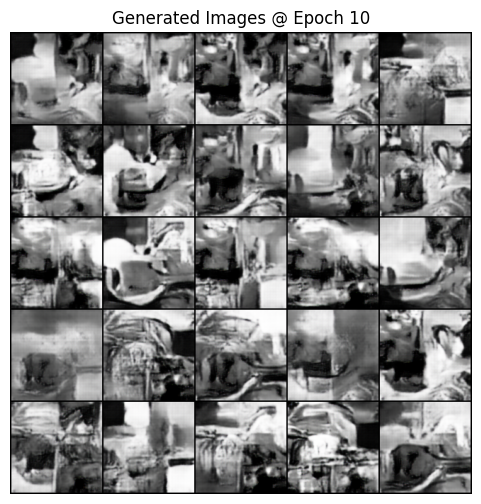

Epoch 11: D_loss=1.2448  G_loss=0.9102  epoch 0:03:55  ETA 2:32:53


Epoch 12: D_loss=1.2914  G_loss=0.9496  epoch 0:03:54  ETA 2:28:58


Epoch 13: D_loss=1.2497  G_loss=0.7911  epoch 0:03:56  ETA 2:25:06


Epoch 14: D_loss=1.2568  G_loss=0.7969  epoch 0:03:54  ETA 2:21:10


Epoch 15: D_loss=1.2754  G_loss=0.9747  epoch 0:03:54  ETA 2:17:15


Epoch 16: D_loss=1.3460  G_loss=0.7063  epoch 0:03:55  ETA 2:13:21


Epoch 17: D_loss=1.2438  G_loss=0.7783  epoch 0:03:55  ETA 2:09:27


Epoch 18: D_loss=1.2987  G_loss=0.8346  epoch 0:03:54  ETA 2:05:31


Epoch 19: D_loss=1.3759  G_loss=0.8528  epoch 0:03:55  ETA 2:01:37


Epoch 20: D_loss=1.2367  G_loss=0.9459  epoch 0:03:54  ETA 1:57:42


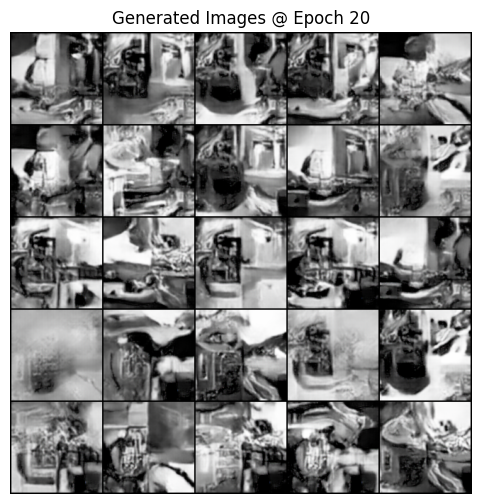

Epoch 21: D_loss=1.3404  G_loss=1.0001  epoch 0:03:54  ETA 1:53:46


Epoch 22: D_loss=1.2707  G_loss=0.8236  epoch 0:03:54  ETA 1:49:50


Epoch 23: D_loss=1.2345  G_loss=0.8422  epoch 0:03:55  ETA 1:45:55


Epoch 24: D_loss=1.2886  G_loss=0.7551  epoch 0:03:55  ETA 1:42:00


Epoch 25: D_loss=1.3485  G_loss=0.9684  epoch 0:03:54  ETA 1:38:04


Epoch 26: D_loss=1.3273  G_loss=0.9049  epoch 0:03:54  ETA 1:34:09


Epoch 27: D_loss=1.3120  G_loss=0.6896  epoch 0:03:55  ETA 1:30:14


Epoch 28: D_loss=1.3480  G_loss=0.8174  epoch 0:03:55  ETA 1:26:19


Epoch 29: D_loss=1.2586  G_loss=0.9974  epoch 0:03:54  ETA 1:22:23


Epoch 30: D_loss=1.3077  G_loss=0.7252  epoch 0:03:54  ETA 1:18:27


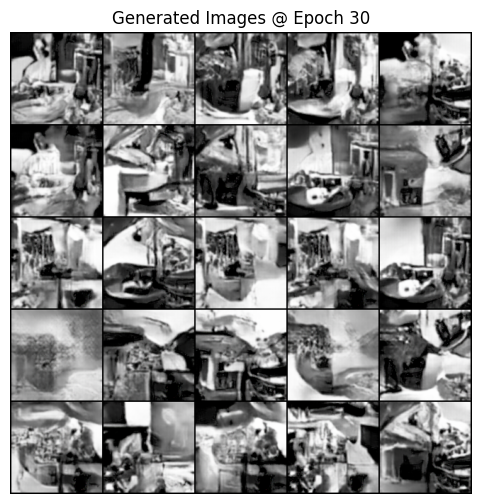

Epoch 31: D_loss=1.2743  G_loss=0.8731  epoch 0:03:55  ETA 1:14:32


Epoch 32: D_loss=1.2982  G_loss=0.8225  epoch 0:03:55  ETA 1:10:37


Epoch 33: D_loss=1.3288  G_loss=0.7827  epoch 0:03:54  ETA 1:06:41


Epoch 34: D_loss=1.3393  G_loss=0.5809  epoch 0:03:54  ETA 1:02:46


Epoch 35: D_loss=1.3339  G_loss=0.8218  epoch 0:03:53  ETA 0:58:50


Epoch 36: D_loss=1.2968  G_loss=0.9666  epoch 0:03:55  ETA 0:54:54


Epoch 37: D_loss=1.2900  G_loss=0.8773  epoch 0:03:54  ETA 0:50:59


Epoch 38: D_loss=1.2720  G_loss=0.8474  epoch 0:03:55  ETA 0:47:04


Epoch 39: D_loss=1.3417  G_loss=0.8035  epoch 0:03:54  ETA 0:43:08


Epoch 40: D_loss=1.2918  G_loss=0.8512  epoch 0:03:55  ETA 0:39:13


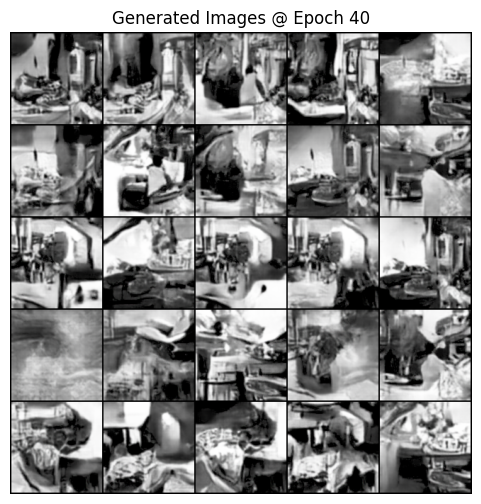

Epoch 41: D_loss=1.3468  G_loss=0.7798  epoch 0:03:54  ETA 0:35:18


Epoch 42: D_loss=1.4175  G_loss=0.9487  epoch 0:03:56  ETA 0:31:23


Epoch 43: D_loss=1.3576  G_loss=0.7520  epoch 0:03:54  ETA 0:27:27


Epoch 44: D_loss=1.3370  G_loss=0.7033  epoch 0:03:54  ETA 0:23:32


Epoch 45: D_loss=1.3278  G_loss=0.7710  epoch 0:03:56  ETA 0:19:36


Epoch 46: D_loss=1.3379  G_loss=0.8562  epoch 0:03:56  ETA 0:15:41


Epoch 47: D_loss=1.3529  G_loss=0.6730  epoch 0:03:55  ETA 0:11:46


Epoch 48: D_loss=1.3612  G_loss=0.7146  epoch 0:03:55  ETA 0:07:50


Epoch 49: D_loss=1.3255  G_loss=0.8010  epoch 0:03:55  ETA 0:03:55


Epoch 50: D_loss=1.3230  G_loss=0.5615  epoch 0:03:54  ETA 0:00:00


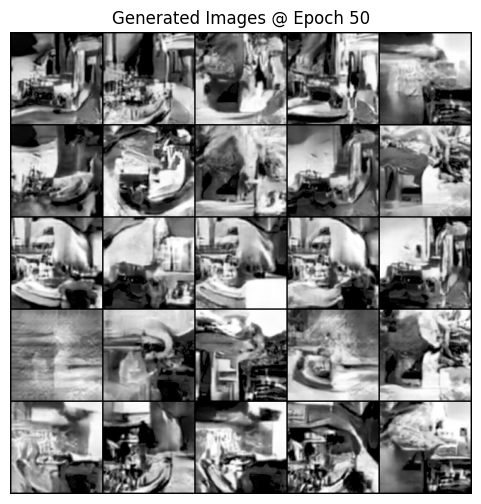

Training complete.

Total training time: 3:16:11


In [20]:
device = "cuda" if torch.cuda.is_available() else "cpu"
z_dim = 100
lr = 2e-4
epochs = 50
sample_size = 10000
batch_size = 64

G = Generator(z_dim=z_dim).to(device)
D = Discriminator().to(device)


criterion = nn.BCELoss()
optimizer_G = torch.optim.Adam(G.parameters(), lr=lr, betas=(0.5, 0.999))
optimizer_D = torch.optim.Adam(D.parameters(), lr=lr, betas=(0.5, 0.999))

fixed_noise = torch.randn(25, z_dim, 1, 1, device=device)
overall_start = time.time()


for epoch in range(epochs):
    epoch_start = time.time()

    for real, _ in tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False):
        real = real.to(device, non_blocking=True)
        batch_size = real.size(0)

        noise = torch.randn(batch_size, z_dim, 1, 1, device=device)
        fake = G(noise)

        real_labels = torch.ones(batch_size, 1, device=device)
        fake_labels = torch.zeros(batch_size, 1, device=device)

        D_real = D(real)
        D_fake = D(fake.detach())
        d_loss = criterion(D_real, real_labels) + criterion(D_fake, fake_labels)
        optimizer_D.zero_grad()
        d_loss.backward()
        optimizer_D.step()

        fake = G(noise)
        g_loss = criterion(D(fake), real_labels)
        optimizer_G.zero_grad()
        g_loss.backward()
        optimizer_G.step()

    epoch_secs = time.time() - epoch_start
    total_secs = time.time() - overall_start
    avg_epoch = total_secs / (epoch + 1)
    remaining = avg_epoch * (epochs - epoch - 1)

    print(f"Epoch {epoch+1:02d}: D_loss={d_loss.item():.4f}  G_loss={g_loss.item():.4f}  "
          f"epoch {timedelta(seconds=int(epoch_secs))}  ETA {timedelta(seconds=int(remaining))}")

    if (epoch + 1) % 10 == 0 or epoch == epochs - 1:
        with torch.no_grad():
            fake_images = G(fixed_noise).detach().cpu()
        grid = make_grid(fake_images, nrow=5, normalize=True)
        plt.figure(figsize=(6, 6))
        plt.imshow(grid.permute(1, 2, 0))
        plt.axis("off")
        plt.title(f"Generated Images @ Epoch {epoch+1}")
        os.makedirs("generated", exist_ok=True)
        plt.savefig(f"generated/DCGAN_epoch_{epoch+1}.png")
        plt.show()

print("Training complete.")
total_training_time = time.time() - overall_start
print(f"\nTotal training time: {timedelta(seconds=int(total_training_time))}")

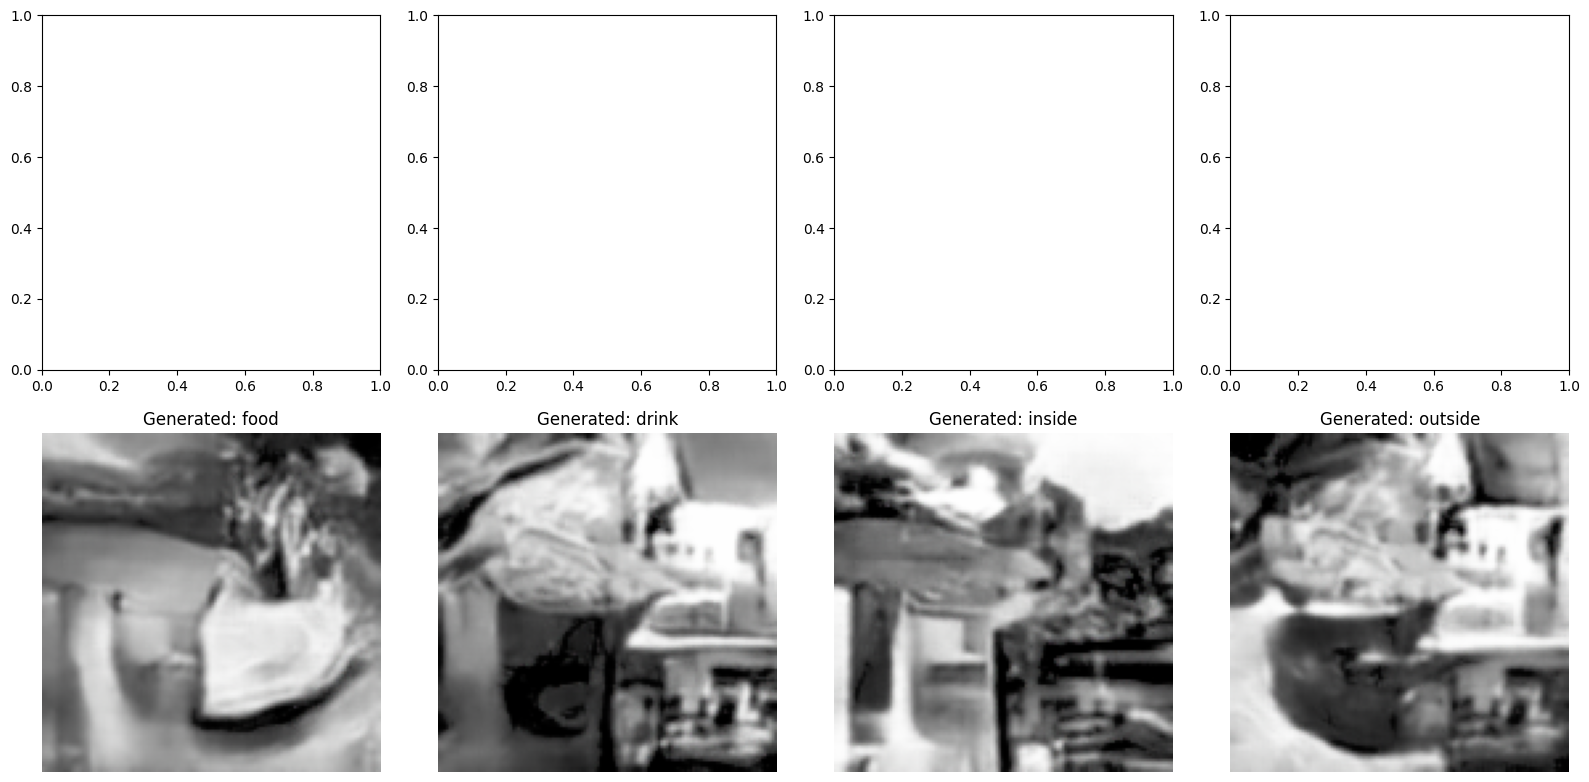

In [21]:
labels = ['food', 'drink', 'inside', 'outside']
G.eval()

fake_images = []
for _ in labels:
    z = torch.randn(1, z_dim, 1, 1, device=device)
    with torch.no_grad():
        fake_img = G(z).cpu()
    fake_images.append(fake_img)

def get_one_real_image_per_class(dataloader, target_labels):
    found = {}
    for imgs, lbls in dataloader:
        for img, lbl in zip(imgs, lbls):
            cls_name = full_dataset.classes[lbl]
            if cls_name in target_labels and cls_name not in found:
                found[cls_name] = img
            if len(found) == len(target_labels):
                return found
    return found

real_images_dict = get_one_real_image_per_class(dataloader, labels)

fig, axes = plt.subplots(2, len(labels), figsize=(4*len(labels), 8))
for i, cls in enumerate(labels):
    fake = fake_images[i][0] * 0.5 + 0.5
    axes[1, i].imshow(fake.permute(1, 2, 0).numpy())
    axes[1, i].set_title(f"Generated: {cls}")
    axes[1, i].axis("off")

plt.tight_layout()
plt.show()

In [23]:
!pip install torchmetrics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 19.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 122.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 89.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 59.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 6.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 75.8 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstal

In [33]:
os.makedirs("model_weights", exist_ok=True)
torch.save({
    'generator_state_dict': G.state_dict(),
    'discriminator_state_dict': D.state_dict(),
    'z_dim': z_dim,
    'image_size': image_size,
    'batch_size': batch_size,
    'sample_size': sample_size,
    'epochs': epochs,
    'class_labels': labels,
    'model_type': 'DCGAN',
    'transform_description': "ToTensor + Normalize([0.5]*3, [0.5]*3)"
}, "model_weights/DCGAN_checkpoint.pth")

print("Model and config saved to 'model_weights/DCGAN_checkpoint.pth'")

Model and config saved to 'model_weights/DCGAN_checkpoint.pth'


In [34]:
!pip install -q lime

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.7/275.7 kB 7.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


  0%|          | 0/1000 [00:00<?, ?it/s]

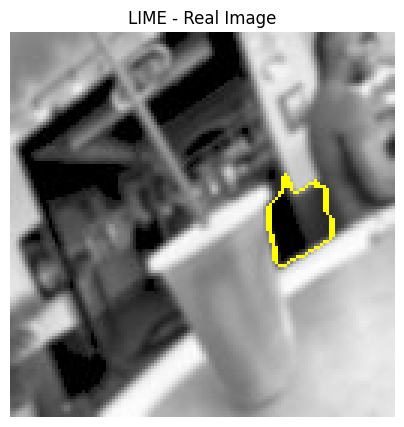

  0%|          | 0/1000 [00:00<?, ?it/s]

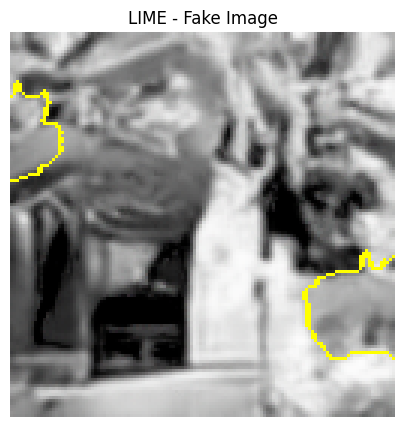

In [53]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
from torchvision import transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

D.eval()

real_img, _ = next(iter(dataloader))
real_img = real_img[0].unsqueeze(0).to(device)

noise = torch.randn(1, z_dim, 1, 1, device=device)
fake_img = G(noise).detach().to(device)

explainer = lime_image.LimeImageExplainer()

def lime_predict(images_np):
    imgs = images_np.astype(np.float32) / 255.0
    imgs = (imgs - 0.5) / 0.5
    imgs = torch.tensor(imgs.transpose((0, 3, 1, 2)), dtype=torch.float32)
    with torch.no_grad():
        preds = D(imgs.to(device)).cpu().numpy()
    return preds

def run_lime_and_plot(img_tensor, title="Image"):
    img_np = (img_tensor.squeeze().cpu() * 0.5 + 0.5).permute(1, 2, 0).numpy()
    img_np_uint8 = (img_np * 255).astype(np.uint8)
    explanation = explainer.explain_instance(
        image=img_np_uint8,
        classifier_fn=lime_predict,
        top_labels=1,
        hide_color=0,
        num_samples=1000
    )
    temp, mask = explanation.get_image_and_mask(
        label=explanation.top_labels[0],
        positive_only=True,
        num_features=5,
        hide_rest=False
    )
    plt.figure(figsize=(5, 5))
    plt.imshow(mark_boundaries(temp, mask))
    plt.title(title)
    plt.axis("off")
    plt.show()

run_lime_and_plot(real_img, title="LIME - Real Image")
run_lime_and_plot(fake_img, title="LIME - Fake Image")

In [36]:
!pip install optuna


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 395.9/395.9 kB 11.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 247.0/247.0 kB 24.8 MB/s eta 0:00:00


In [37]:
import optuna
from optuna.trial import Trial
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, Subset
from torchvision.utils import make_grid
import matplotlib.pyplot as plt
import os
import random
import numpy as np

In [46]:
param_space = {
    "z_dim": [64, 100, 128],
    "features": [32, 64],
    "lr": [0.0002, 0.00005],
    "beta1": [0.5, 0.7]
}


In [47]:
def sample_hparams():
    return {
        "z_dim": random.choice(param_space["z_dim"]),
        "features": random.choice(param_space["features"]),
        "lr": random.choice(param_space["lr"]),
        "beta1": random.choice(param_space["beta1"])
    }


In [50]:
def quick_train(hparams):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    G = Generator(z_dim=hparams['z_dim'], features=hparams['features']).to(device)
    D = Discriminator(features=hparams['features']).to(device)

    optimizer_G = optim.Adam(G.parameters(), lr=hparams['lr'], betas=(hparams['beta1'], 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=hparams['lr'], betas=(hparams['beta1'], 0.999))
    criterion = nn.BCELoss()

    batch_size = 32
    z = torch.randn(batch_size, hparams['z_dim'], 1, 1).to(device)
    fake_imgs = G(z)
    real_imgs = torch.randn(batch_size, 3, 128, 128).to(device)

    real_labels = torch.ones(batch_size, 1).to(device)
    fake_labels = torch.zeros(batch_size, 1).to(device)
    D_loss_real = criterion(D(real_imgs), real_labels)
    D_loss_fake = criterion(D(fake_imgs.detach()), fake_labels)
    D_loss = D_loss_real + D_loss_fake
    optimizer_D.zero_grad()
    D_loss.backward()
    optimizer_D.step()

    G_loss = criterion(D(fake_imgs), real_labels)
    optimizer_G.zero_grad()
    G_loss.backward()
    optimizer_G.step()

    return D_loss.item(), G_loss.item()

results = []
for i in range(5):
    hparams = sample_hparams()
    d_loss, g_loss = quick_train(hparams)
    hparams['D_loss'] = d_loss
    hparams['G_loss'] = g_loss
    results.append(hparams)
    print(f"Trial {i+1}: {hparams}")

Trial 1: {'z_dim': 64, 'features': 64, 'lr': 5e-05, 'beta1': 0.5, 'D_loss': 1.399979829788208, 'G_loss': 0.7677661776542664}
Trial 2: {'z_dim': 64, 'features': 64, 'lr': 5e-05, 'beta1': 0.7, 'D_loss': 1.4023559093475342, 'G_loss': 0.8101929426193237}
Trial 3: {'z_dim': 64, 'features': 32, 'lr': 5e-05, 'beta1': 0.5, 'D_loss': 1.3767669200897217, 'G_loss': 0.8236232995986938}
Trial 4: {'z_dim': 64, 'features': 64, 'lr': 0.0002, 'beta1': 0.7, 'D_loss': 1.4322515726089478, 'G_loss': 0.848839521408081}
Trial 5: {'z_dim': 100, 'features': 64, 'lr': 0.0002, 'beta1': 0.7, 'D_loss': 1.373216986656189, 'G_loss': 0.8507187366485596}


Best Hyperparameter Configuration:
 z_dim       64.000000
features    64.000000
lr           0.000050
beta1        0.500000
D_loss       1.399980
G_loss       0.767766
Name: 0, dtype: float64


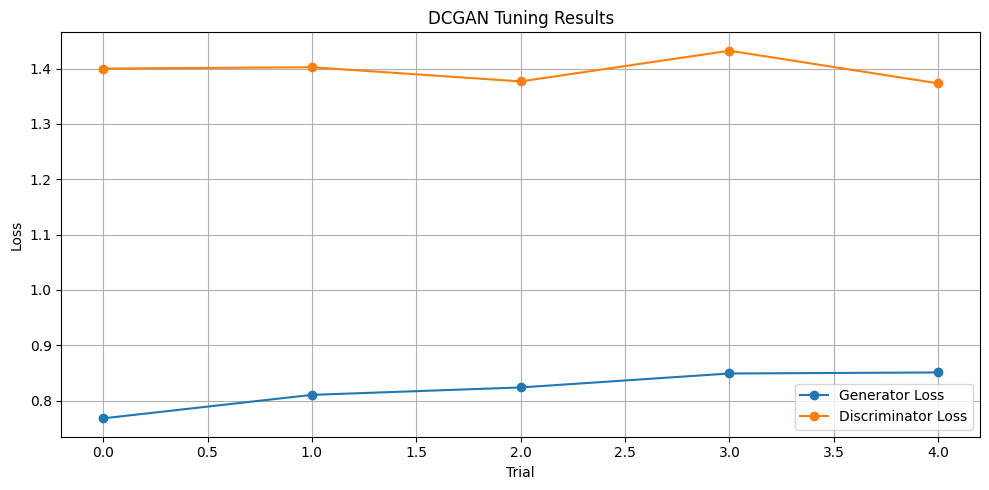

In [51]:
import pandas as pd
import matplotlib.pyplot as plt

results_df = pd.DataFrame(results)

best_config = results_df.sort_values(by="G_loss").iloc[0]
print("Best Hyperparameter Configuration:\n", best_config)

plt.figure(figsize=(10, 5))
plt.plot(results_df.index, results_df["G_loss"], marker='o', label='Generator Loss')
plt.plot(results_df.index, results_df["D_loss"], marker='o', label='Discriminator Loss')
plt.title("DCGAN Tuning Results")
plt.xlabel("Trial")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()